In [64]:
import numpy as np
import pylab as plt
import networkx as nx
import pandas as pd
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import os

In [4]:
# Torus module imports
from modules import graphio
from modules import visualization as vis
from modules.projector import MDSTorusProjector

In [67]:
res_path = os.path.join(os.path.expanduser("~/data/graph_torus/figures"))

## Lattice graph

In [ ]:
G,D = graphio.get_periodic_lattice(20,20)

#Normalize or don't
# D /= np.max(D)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(D)

fig, ax = plt.subplots()

vis.plot_embedding_with_torus_edges(X_torus, G, ax=ax)

In [5]:
G40, D40 = graphio.get_periodic_lattice(20, 40)

[alpha]  alpha=25.13
[square]  r=39.08
[rectangular]  r0=39.23  r1=38.89  ratio=0.991


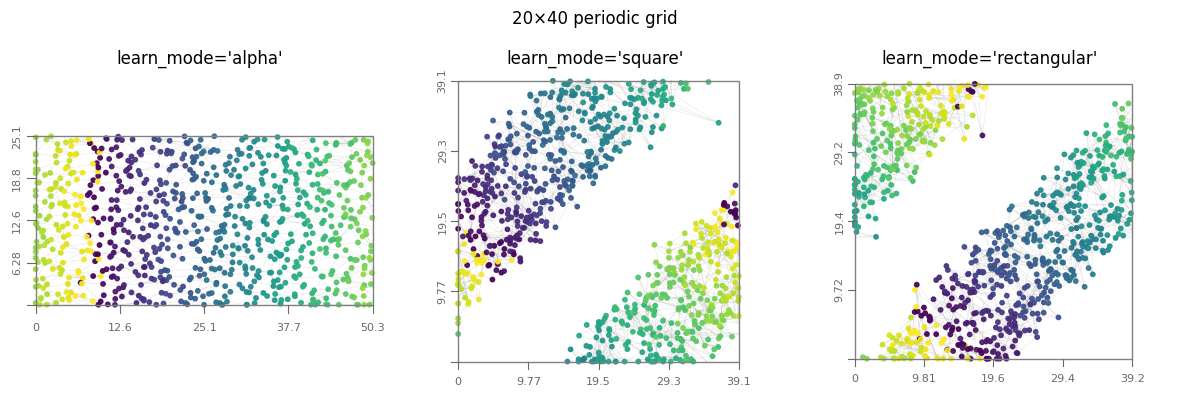

In [8]:
colors = [j for (i, j) in G40.nodes()]
colors_short = [i for (i, j) in G40.nodes()]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    proj.fit_transform(D40,
                       learn_mode=mode,
                       r0_init=2.0,
                       r1_init=1.0,)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_ / proj.r0_:.3f}")
    vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=ax, colors=colors)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×40 periodic grid")
plt.tight_layout()

In [9]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh


def lowest_laplacian_eigenvalues(
    D,
    k=15,
    sigma=None,
    n_eigs=6,
    normalized=True,
):
    """
    Compute the lowest eigenvalues of a symmetrized graph Laplacian
    from a pairwise distance matrix.

    Parameters
    ----------
    D : (n, n) array
        Pairwise distance matrix.
    k : int
        Number of nearest neighbors per point.
    sigma : float or None
        Gaussian kernel bandwidth. If None, uses median kNN distance.
    n_eigs : int
        Number of lowest eigenvalues to compute.
    normalized : bool
        If True, use symmetric normalized Laplacian:
            L = I - D^{-1/2} W D^{-1/2}
        If False, use unnormalized Laplacian:
            L = D - W

    Returns
    -------
    evals : (n_eigs,) array
        Lowest eigenvalues.
    evecs : (n, n_eigs) array
        Corresponding eigenvectors.
    """

    D = np.asarray(D)
    n = D.shape[0]

    if D.shape != (n, n):
        raise ValueError("D must be a square distance matrix.")

    if sigma is None:
        k = min(k, n-1)
        knn_dists = np.partition(D, kth=k, axis=1)[:, 1:k + 1]
        sigma = np.median(knn_dists)

    # kNN indices, excluding self
    nn_idx = np.argpartition(D, kth=k, axis=1)[:, 1:k + 1]

    rows = np.repeat(np.arange(n), k)
    cols = nn_idx.ravel()
    vals = np.exp(-(D[rows, cols] ** 2) / (2 * sigma**2))

    W = csr_matrix((vals, (rows, cols)), shape=(n, n))

    # Symmetrize graph, but D should already be symmetric
    W = W.maximum(W.T)

    degrees = np.asarray(W.sum(axis=1)).ravel()

    if normalized:
        inv_sqrt_deg = np.zeros_like(degrees)
        mask = degrees > 0
        inv_sqrt_deg[mask] = 1.0 / np.sqrt(degrees[mask])

        D_inv_sqrt = diags(inv_sqrt_deg)
        L = diags(np.ones(n)) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        L = diags(degrees) - W

    evals, evecs = eigsh(L, k=n_eigs, which="SM")

    order = np.argsort(evals)
    return evals[order], evecs[:, order]

In [39]:
# earlier version, which does not account for the higher harmonics
def estimate_flat_torus_aspect_ratio(
    D,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=6,
    zero_tol=1e-8,
):
    """
    Estimate the aspect ratio L_max / L_min of a flat 2-torus
    from a distance matrix using graph Laplacian eigenvalues.

    Assumes the first nonzero Laplacian eigenspace has multiplicity 2
    and the second nonzero eigenspace also has multiplicity 2.

    Parameters
    ----------
    D : (n, n) array
        Pairwise distance matrix.
    k : int
        Number of nearest neighbors for graph construction.
    sigma : float or None
        Gaussian kernel bandwidth.
    normalized : bool
        Whether to use the symmetric normalized graph Laplacian.
    n_eigs : int
        Number of eigenvalues to compute. Should be at least 6.
    zero_tol : float
        Threshold for treating eigenvalues as zero.

    Returns
    -------
    aspect_ratio : float
        Estimated L_max / L_min.
    info : dict
        Diagnostic information.
    """

    if n_eigs < 6:
        raise ValueError("n_eigs should be at least 6.")

    evals, evecs = lowest_laplacian_eigenvalues(
        D,
        k=k,
        sigma=sigma,
        n_eigs=n_eigs,
        normalized=normalized,
    )

    # Remove near-zero eigenvalues, usually one for a connected graph
    nonzero = evals[evals > zero_tol]

    if len(nonzero) < 4:
        raise ValueError(
            "Need at least four nonzero eigenvalues to estimate "
            "the two torus frequency pairs."
        )

    # Continuous theory:
    # lambda_1 ~= lambda_2 ~= 4 pi^2 / L_max^2
    # lambda_3 ~= lambda_4 ~= 4 pi^2 / L_min^2
    #
    # Hence:
    # L_max / L_min ~= sqrt(lambda_3 / lambda_1)
    #
    # Use pair averages for stability.
    lambda_low_pair = np.mean(nonzero[0:2])
    lambda_high_pair = np.mean(nonzero[2:4])

    aspect_ratio = np.sqrt(lambda_high_pair / lambda_low_pair)

    info = {
        "all_eigenvalues": evals,
        "nonzero_eigenvalues": nonzero,
        "lambda_low_pair": lambda_low_pair,
        "lambda_high_pair": lambda_high_pair,
        "pair_splitting_low": abs(nonzero[1] - nonzero[0]),
        "pair_splitting_high": abs(nonzero[3] - nonzero[2]),
        "aspect_ratio": aspect_ratio,
        "eigenvectors": evecs,
    }

    return aspect_ratio, info

In [78]:
# helper functions for filtering harmonics
def _phase_from_pair(evec_pair, eps=1e-12):
    """
    Convert a 2D eigenvector pair into circular phases.

    Parameters
    ----------
    evec_pair : (n, 2) array

    Returns
    -------
    z : (n,) complex array
        Unit-modulus complex phase representation.
    theta : (n,) array
        Angles in [-pi, pi].
    """
    u = evec_pair[:, 0]
    v = evec_pair[:, 1]

    # Center for numerical stability, but should ideally be centered already...
    u = u - np.mean(u)
    v = v - np.mean(v)

    z = u + 1j * v
    z = z / np.maximum(np.abs(z), eps)

    theta = np.angle(z)
    return z, theta


def torus_init_from_eigenpairs(pair1, pair2):
    _, theta1 = _phase_from_pair(pair1)
    _, theta2 = _phase_from_pair(pair2)

    x = np.mod(theta1, 2 * np.pi) / (2 * np.pi)
    y = np.mod(theta2, 2 * np.pi) / (2 * np.pi)

    return np.column_stack([x, y])

def harmonic_score(z_candidate, z_reference, m):
    """
    Score whether candidate phase is approximately an m-th harmonic
    of the reference phase.

    Score is in [0, 1].
    Near 1 means:
        theta_candidate ~=  m * theta_reference + const
    or
        theta_candidate ~= -m * theta_reference + const
    """
    score_pos = np.abs(np.mean(z_candidate * np.conj(z_reference ** m)))
    score_neg = np.abs(np.mean(z_candidate * (z_reference ** m)))
    return max(score_pos, score_neg)

# main function to find the
def find_fundamental_torus_directions(
    D,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=20,
    zero_tol=1e-8,
    harmonic_threshold=0.75,
    max_harmonic=8,
):
    """
    Find the first two independent torus directions from graph Laplacian
    eigenvectors, skipping harmonics.

    Requires the function `lowest_laplacian_eigenvalues` from above.

    Returns
    -------
    result : dict
        Contains eigenvalues, accepted fundamental pairs, skipped harmonics,
        and estimated aspect ratio.
    """

    evals, evecs = lowest_laplacian_eigenvalues(
        D,
        k=k,
        sigma=sigma,
        n_eigs=n_eigs,
        normalized=normalized,
    )

    # Remove zero modes
    nz_idx = np.flatnonzero(evals > zero_tol)
    if len(nz_idx) < 4:
        raise ValueError("Need at least four nonzero eigenvectors.")

    evals_nz = evals[nz_idx]
    evecs_nz = evecs[:, nz_idx]

    # Treat consecutive eigenvectors as approximate sin/cos pairs
    candidate_pairs = []
    for j in range(0, len(evals_nz) - 1, 2):
        lam_pair = evals_nz[j:j + 2]
        vec_pair = evecs_nz[:, j:j + 2]

        z, theta = _phase_from_pair(vec_pair)

        candidate_pairs.append({
            "pair_index": j // 2,
            "eigenvalue_indices": nz_idx[j:j + 2],
            "eigenvalues": lam_pair,
            "lambda_mean": float(np.mean(lam_pair)),
            "lambda_splitting": float(abs(lam_pair[1] - lam_pair[0])),
            "eigenvectors": vec_pair,
            "z": z,
            "theta": theta,
        })

    accepted = []
    skipped = []

    for cand in candidate_pairs:
        is_harmonic = False
        best_match = None

        for ref_id, ref in enumerate(accepted):
            scores = [
                harmonic_score(cand["z"], ref["z"], m)
                for m in range(1, max_harmonic + 1)
            ]

            best_m = int(np.argmax(scores) + 1)
            best_score = float(np.max(scores))

            if best_score >= harmonic_threshold:
                is_harmonic = True
                best_match = {
                    "reference_direction": ref_id,
                    "harmonic": best_m,
                    "score": best_score,
                }
                break

        if is_harmonic:
            cand_out = {
                "pair_index": cand["pair_index"],
                "eigenvalues": cand["eigenvalues"],
                "lambda_mean": cand["lambda_mean"],
                "matched_to": best_match,
            }
            skipped.append(cand_out)
        else:
            accepted.append(cand)

        if len(accepted) == 2:
            break

    if len(accepted) < 2:
        raise ValueError(
            "Could not identify two independent torus directions. "
            "Try increasing n_eigs or max_harmonic, or lowering harmonic_threshold."
        )

    lambda_1 = accepted[0]["lambda_mean"]
    lambda_2 = accepted[1]["lambda_mean"]

    aspect_ratio = np.sqrt(lambda_2 / lambda_1)

    return {
        "aspect_ratio": aspect_ratio,
        "all_eigenvalues": evals,
        "nonzero_eigenvalues": evals_nz,
        "fundamental_directions": [
            {
                "lambda_mean": a["lambda_mean"],
                "eigenvalues": a["eigenvalues"],
                "lambda_splitting": a["lambda_splitting"],
                "theta": a["theta"],
                "eigenvectors": a["eigenvectors"],
            }
            for a in accepted
        ],
        "skipped_harmonics": skipped,
    }

In [79]:
# test procedure on a periodic grid with aspect ratio 4

G, D = graphio.get_periodic_lattice(20, 80)


In [80]:
evals, evecs = lowest_laplacian_eigenvalues(D, k=15, n_eigs=8)

In [81]:
evals

array([1.34591602e-17, 4.28869323e-03, 4.33719349e-03, 1.71163026e-02,
       1.71815479e-02, 3.80956310e-02, 3.82929671e-02, 6.64580770e-02])

In [82]:
estimate_flat_torus_aspect_ratio(D)[0] # does not work because it does not test for the higher harmonics!

np.float64(1.9940294867910915)

In [83]:
result = find_fundamental_torus_directions(
    D,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=30,
    harmonic_threshold=0.75,
    max_harmonic=10,
)

print("Estimated aspect ratio:", result["aspect_ratio"])
print("Nonzero eigenvalues:")
print(result["nonzero_eigenvalues"][:12])

print("Skipped harmonics:")
for h in result["skipped_harmonics"]:
    print(h)

Estimated aspect ratio: 3.966797261129058
Nonzero eigenvalues:
[0.00428869 0.00433719 0.0171163  0.01718155 0.03809563 0.03829297
 0.06645808 0.06696101 0.0676131  0.06811937 0.07112282 0.07199988]
Skipped harmonics:
{'pair_index': 1, 'eigenvalues': array([0.0171163 , 0.01718155]), 'lambda_mean': 0.017148925248303803, 'matched_to': {'reference_direction': 0, 'harmonic': 2, 'score': 0.9998923360876817}}
{'pair_index': 2, 'eigenvalues': array([0.03809563, 0.03829297]), 'lambda_mean': 0.038194299060204856, 'matched_to': {'reference_direction': 0, 'harmonic': 3, 'score': 0.9998296722866281}}
{'pair_index': 3, 'eigenvalues': array([0.06645808, 0.06696101]), 'lambda_mean': 0.06670954241792365, 'matched_to': {'reference_direction': 0, 'harmonic': 4, 'score': 0.8414091240750411}}


array([[-0.00901279,  0.03284213],
       [-0.00670243,  0.03510617],
       [-0.00404388,  0.03494125],
       ...,
       [-0.0179529 ,  0.03225949],
       [-0.01460493,  0.03270879],
       [-0.01226059,  0.03418146]], shape=(1600, 2))

In [86]:
# fundamental_directions hold the eigenvectors corresponding to the fundamental directions
# use them to initialize the graph
init = torus_init_from_eigenpairs(result["fundamental_directions"][0]["eigenvectors"],
                                  result["fundamental_directions"][1]["eigenvectors"])


In [89]:
init.shape

(1600, 2)

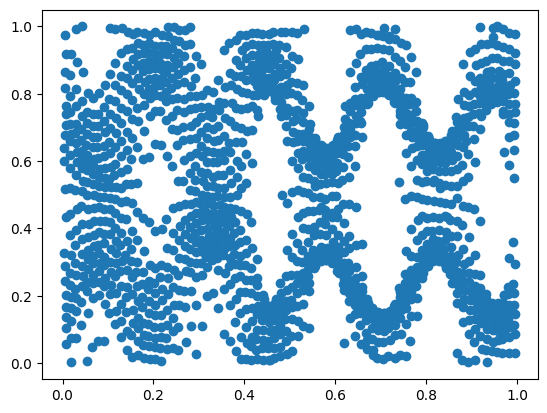

In [88]:
plt.scatter(*init.T)

(np.float64(-0.062287311181301),
 np.float64(0.061804467530358835),
 np.float64(-0.04667771485448475),
 np.float64(0.04663191123735797))

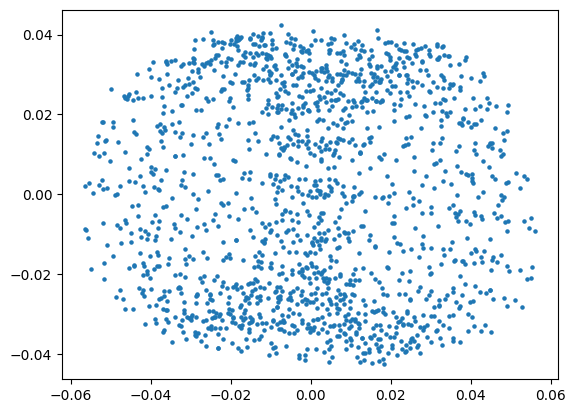

In [91]:
plt.scatter(result["fundamental_directions"][1]["eigenvectors"][:, 0], result["fundamental_directions"][1]["eigenvectors"][:, 1], s=5)
plt.axis("equal")

In [ ]:
# use the eigenvector pair as init
fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=G, X=, ax=ax)

In [50]:
# test against a non-toroidal graph, here a sbm
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
# nx.nx_pydot.write_dot(G,"out.gv")
D, nodes = graphio.apsp_distance_matrix(G)

In [51]:
result = find_fundamental_torus_directions(
    D,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=30,
    harmonic_threshold=0.75,
    max_harmonic=10,
)

print("Estimated aspect ratio:", result["aspect_ratio"])
print("Nonzero eigenvalues:")
print(result["nonzero_eigenvalues"][:12])

print("Skipped harmonics:")
for h in result["skipped_harmonics"]:
    print(h)

Estimated aspect ratio: 1.8618802701733763
Nonzero eigenvalues:
[0.17377012 0.18178121 0.18528222 0.1972685  0.61516403 0.61738954
 0.62007862 0.62156454 0.62839477 0.63148248 0.63745448 0.63890022]
Skipped harmonics:
{'pair_index': 1, 'eigenvalues': array([0.18528222, 0.1972685 ]), 'lambda_mean': 0.19127536226088437, 'matched_to': {'reference_direction': 0, 'harmonic': 2, 'score': 0.7807072126502698}}


In [57]:

def benchmark_periodic_lattice_aspect_ratios(
    graphio,
    pairs=None,
    n_pairs=100,
    seed=None,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=40,
    zero_tol=1e-8,
    harmonic_threshold=0.75,
    max_harmonic=10,
    verbose=True,
):
    """
    Benchmark spectral aspect-ratio estimation on periodic lattice graphs.

    Assumes:
        G, D = graphio.get_periodic_lattice(short_side, long_side)

    and that `find_fundamental_torus_directions` is already defined.

    By default, draws n_pairs random (short_side, aspect_ratio) pairs with
    short_side uniform in [5, 40] and aspect_ratio uniform in [1, 10],
    keeping only pairs where long_side = round(aspect_ratio * short_side) <= 100.

    Parameters
    ----------
    graphio : module-like object
        Must provide graphio.get_periodic_lattice(m, n).
    pairs : list of (int, float) or None
        Explicit list of (short_side, aspect_ratio) pairs to test.
        When provided, n_pairs and seed are ignored.
    n_pairs : int
        Number of random pairs to generate when pairs is None.
    seed : int or None
        Random seed for reproducibility.
    k, sigma, normalized, n_eigs, zero_tol :
        Passed to find_fundamental_torus_directions.
    harmonic_threshold, max_harmonic :
        Harmonic filtering parameters.
    verbose : bool
        Print failures and progress.

    Returns
    -------
    results : list of dict
        One entry per successful computation.
    failures : list of dict
        One entry per failed computation.
    """

    if pairs is None:
        rng = np.random.default_rng(seed=seed)
        pairs = []
        while len(pairs) < n_pairs:
            s = int(rng.integers(5, 41))       # uniform integer in [5, 40]
            r = float(rng.uniform(1.0, 10.0))  # uniform float in [1, 10]
            if int(round(r * s)) <= 100:
                pairs.append((s, r))

    results = []
    failures = []

    for s, r in pairs:
        l = int(round(r * s))

        if l < s or l > 100:
            continue

        true_ratio = l / s

        try:
            G, D = graphio.get_periodic_lattice(s, l)

            out = find_fundamental_torus_directions(
                D,
                k=k,
                sigma=sigma,
                normalized=normalized,
                n_eigs=n_eigs,
                zero_tol=zero_tol,
                harmonic_threshold=harmonic_threshold,
                max_harmonic=max_harmonic,
            )

            estimated_ratio = out["aspect_ratio"]

            results.append({
                "short_side": s,
                "long_side": l,
                "true_aspect_ratio": true_ratio,
                "estimated_aspect_ratio": estimated_ratio,
                "abs_error": abs(estimated_ratio - true_ratio),
                "rel_error": abs(estimated_ratio - true_ratio) / true_ratio,
                "eigenvalues": out["nonzero_eigenvalues"],
                "skipped_harmonics": out["skipped_harmonics"],
            })

            if verbose:
                print(
                    f"s={s:2d}, l={l:3d}, "
                    f"true={true_ratio:5.2f}, "
                    f"est={estimated_ratio:7.3f}"
                )

        except Exception as e:
            failures.append({
                "short_side": s,
                "long_side": l,
                "true_aspect_ratio": true_ratio,
                "error": repr(e),
            })

            if verbose:
                print(
                    f"FAILED: s={s}, l={l}, "
                    f"true={true_ratio:.2f}: {e}"
                )

    return results, failures


In [62]:

def plot_aspect_ratio_benchmark(results):
    """
    Plot estimated vs true aspect ratio.
    """

    true = np.array([r["true_aspect_ratio"] for r in results])
    estimated = np.array([r["estimated_aspect_ratio"] for r in results])
    short_sides = np.array([r["short_side"] for r in results])

    fig = plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        true,
        estimated,
        c=short_sides,
        alpha=0.8,
    )

    plt.plot([1, 10], [1, 10], "--", label="ideal")

    plt.xlim(1, 10)
    plt.ylim(1, 10)

    plt.xlabel("True aspect ratio")
    plt.ylabel("Estimated aspect ratio")
    plt.title("Spectral flat-torus aspect ratio estimate")
    plt.colorbar(sc, label="short side length")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fig


In [ ]:

results, failures = benchmark_periodic_lattice_aspect_ratios(
    graphio,
    seed=42,
    k=8,
    sigma=None,
    normalized=True,
    n_eigs=50,
    harmonic_threshold=0.75,
    max_harmonic=12,
)

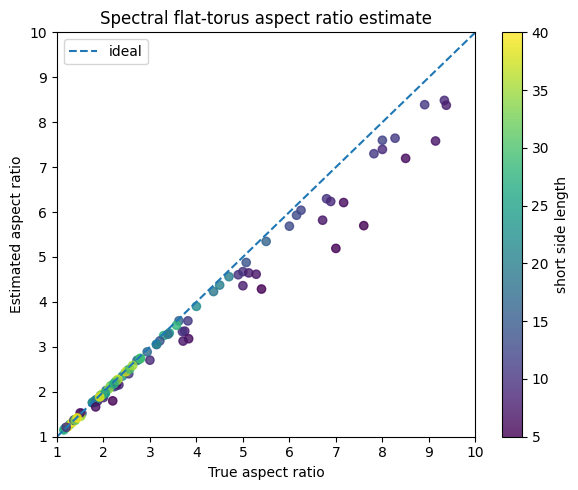

In [68]:
fig = plot_aspect_ratio_benchmark(results)
fig.savefig(os.path.join(res_path, "aspect_ratio_estimates.png"), dpi=300)